# Polynomial Regression

#### Fitting a Non-Linear Curve
##### Dataset: Poly_base.csv
##### The Task: Generate synthetic 2D data using a quadratic function plus some random noise (e.g., y=3x^2 + 2x + 1 + noise).
##### Objectives:
##### Try fitting a standard Linear Regression model and plot it (it will underfit).
##### Use PolynomialFeatures(degree=2) to transform the input x.
##### Fit a Linear Regression model to the polynomial features and plot the resulting curve against the scatter plot of the data.

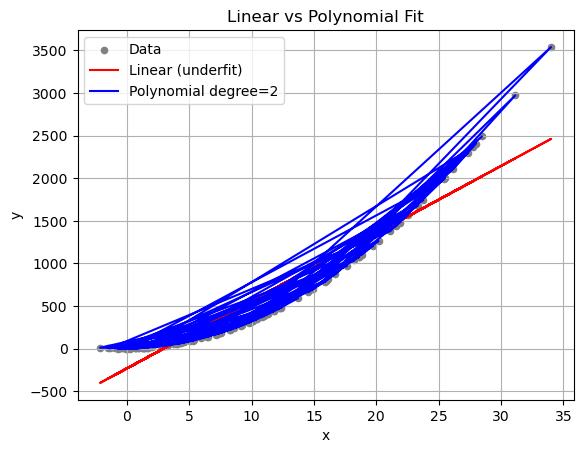

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd
import re

df = pd.read_csv("Poly_base.csv", header=None)
raw = df.to_string()
values = list(map(float, re.findall(r'-?\d+\.?\d*', raw)))
x = np.array(values).reshape(-1, 1)
np.random.seed(42)
y = 3*x**2 + 2*x + 1 + np.random.randn(len(x), 1) * 2
lr = LinearRegression()
lr.fit(x, y)
poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)
pr = LinearRegression()
pr.fit(x_poly, y)
plt.scatter(x, y, color="gray", s=20, label="Data")
plt.plot(x, lr.predict(x), color="red", label="Linear (underfit)")
plt.plot(x, pr.predict(poly.transform(x)), color="blue", label="Polynomial degree=2")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear vs Polynomial Fit")
plt.legend()
plt.grid(True)
plt.show()

#### Visualizing the Bias-Variance Tradeoff
##### Dataset: Complex_Non_linear_dataset.csv
##### The Task: Take a complex, non-linear 1D dataset.
##### Objectives:
##### Fit polynomial regression models of varying degrees (e.g., 1, 2, 5, 10, and 20).
##### For each degree, calculate both the training error and testing error.
##### Plot the degrees on the x-axis and the errors on the y-axis. Identify the point where the model stops learning the underlying pattern and starts memorizing the noise (overfitting).

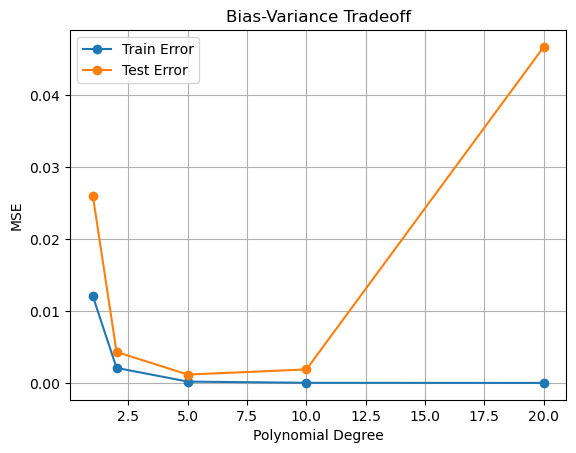

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import re

df = pd.read_csv("Complex_Non_linear_dataset.csv", header=None)
raw = df.to_string()
values = list(map(float, re.findall(r'-?\d+\.?\d*', raw)))
mid = len(values) // 2
x = np.array(values[:mid]).reshape(-1, 1)
y = np.array(values[mid:])
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
degrees = [1, 2, 5, 10, 20]
train_errors = []
test_errors = []
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    model = LinearRegression()
    model.fit(poly.fit_transform(x_train), y_train)
    train_errors.append(mean_squared_error(y_train, model.predict(poly.transform(x_train))))
    test_errors.append(mean_squared_error(y_test, model.predict(poly.transform(x_test))))
plt.plot(degrees, train_errors, marker="o", label="Train Error")
plt.plot(degrees, test_errors, marker="o", label="Test Error")
plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Bias-Variance Tradeoff")
plt.legend()
plt.grid(True)
plt.show()